# Acceptance Rate Model — mô hình khả năng khách chấp nhận giá

**Theo yêu cầu mentor:**

> *"bên cạnh predict giá đối thủ, tụi em làm thêm phần acceptance rate model nha... Ở mấy cái public
> data này chắc tụi em ko access đc customer-level data đâu, nên cứ làm **global model** đc rồi...
> thử tìm cách model xem **khả năng chấp nhận giá của khách tăng hay giảm** knowing **giá đối thủ**
> và cả **thời tiết** nữa, **2 model**"*

| | Nội dung |
|---|---|
| **Phạm vi** | Global model (không cá nhân hoá) — đúng như mentor cho phép |
| **Đầu ra** | 2 model xu hướng: theo **giá đối thủ** và theo **thời tiết** |
| **Mục tiêu** | Xác định **chiều** và **độ lớn tương đối**, không nhằm đạt độ chính xác tuyệt đối |

---

## ⚠️ Tuyên bố minh bạch — đây là MÔ PHỎNG, không phải model học từ hành vi

Bộ dữ liệu **không có nhãn accept/reject**, đã kiểm chứng bằng 2 cách độc lập:

**(1) Generator khai báo thẳng** trong `generation_config.json`:
```
booking_or_completion_outcomes_generated    = False
event_level_production_rows_used_in_release = False
personalized_wrapper_enabled                = False
n_customers                                 = 20000   (có nhưng KHÔNG xuất ra)
```

**(2) Kiểm định placebo** — cầu có phản ứng với giá không?

| Biến | Lag | Tương quan riêng phần (t+k) | (t−k) | Kết luận |
|---|---:|---:|---:|---|
| Cầu | 5p | 0,0040 | 0,0050 | Đối xứng → không nhân quả |
| Cầu | 30p | 0,0100 | 0,0150 | Đối xứng → không nhân quả |
| Cung | 5p | 0,0475 | 0,0469 | Đối xứng → không nhân quả |

Tương quan ~0 và **đối xứng hoàn hảo** giữa tương lai/quá khứ. Giá tương lai không thể tác động
ngược vào quá khứ ⇒ generator **không mô phỏng phản ứng hành vi với giá**.

> **Hệ quả:** elasticity **không thể ước lượng** từ bộ dữ liệu này. Model dưới đây là **mô phỏng
> dựa trên giả định elasticity**, nêu rõ nguồn gốc từng tham số và kèm phân tích độ nhạy.

---

## 🎯 Chỉ 1 tham số là giả định — phần còn lại đo từ dữ liệu

| Tham số | Nguồn | Giá trị |
|---|---|---|
| Dịch chuyển WTP do **mưa** | 📊 Đo từ dữ liệu (hệ số nhân cân bằng) | **+4,61%** |
| Dịch chuyển WTP theo **giờ** | 📊 Đo từ dữ liệu | biên độ **50,0%** |
| Giá tham chiếu thị trường | 📊 Giá đối thủ trong dữ liệu | median **114k** |
| **Độ nhạy giá `β`** | ⚠️ **Giả định** — literature + bằng chứng GMV | xem mục 3 |

## 1. Khung lý thuyết — mô hình logit nhị phân

$$P(\text{chấp nhận} \mid p, \text{ctx}) = \sigma\left(a + b \cdot \log\frac{p}{p_{ref}(\text{ctx})}\right)$$

| Ký hiệu | Ý nghĩa |
|---|---|
| $p$ | giá **mình** báo cho khách |
| $p_{ref}(\text{ctx})$ | **giá tham chiếu thị trường** = giá đối thủ (đã bao gồm surge) |
| $b < 0$ | độ nhạy giá |
| $a = \text{logit}(P_0)$ | mức chấp nhận nền khi giá **ngang bằng** đối thủ |

**Liên hệ elasticity:** $\varepsilon = b(1-P)$, nên $b = \dfrac{\varepsilon_0}{1-P_0}$

**Vì sao dùng tỷ lệ $p/p_{ref}$:** khách không đánh giá "114k đắt hay rẻ" một cách tuyệt đối, mà so
với **lựa chọn thay thế** tại đúng thời điểm đó.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 200)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def b_tu_elasticity(eps0, P0):
    return eps0 / (1.0 - P0)

def P_accept(ty_le_gia, eps0, P0=0.5, dich_WTP=0.0):
    """P(chap nhan). ty_le_gia = gia minh / gia doi thu. dich_WTP: 0.0463 = mua."""
    b = b_tu_elasticity(eps0, P0)
    a = np.log(P0 / (1 - P0))
    return sigmoid(a + b * (np.log(ty_le_gia) - np.log1p(dich_WTP)))

assert abs(P_accept(1.0, -2.0, 0.5) - 0.5) < 1e-12
print("Mo hinh OK.")

Mo hinh OK.


## 2. Hiệu chỉnh tham số bối cảnh **từ dữ liệu thật**

**Ý tưởng:** hệ số nhân quan sát được là **giá cân bằng thị trường**. Nếu khi mưa thị trường chấp
nhận mức giá cao hơn X%, thì X% chính là mức dịch chuyển **sẵn sàng chi trả (WTP)**.

In [2]:
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_price", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
print(f"Nap {len(d):,} dong tho")
# Moi target_request_id xuat hien 4 lan (lag 5/10/15/30) voi CUNG gia/he so nhan
# -> khu trung lap theo ID, KHONG dung drop_duplicates() tren vai cot (se gop nham chuyen khac nhau)
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
print(f"Sau khi khu trung lap theo target_request_id: {len(d):,} chuyen")

gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
print(f"\nHe so nhan: khong mua {gm[False]:.4f} -> mua {gm[True]:.4f}")
print(f"=> DICH CHUYEN WTP do mua = {DICH_MUA*100:+.2f}%")

gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = gh / gh.mean() - 1
print(f"\nWTP theo gio: thap nhat {DICH_GIO.min()*100:+.1f}% (gio {DICH_GIO.idxmin()}h) | "
      f"cao nhat {DICH_GIO.max()*100:+.1f}% (gio {DICH_GIO.idxmax()}h)")
print(f"Bien do: {(gh.max()/gh.min()-1)*100:.1f}%")
print(f"\nGia doi thu median = {d.target_shown_price.median():,.0f} VND")

Nap 6,897,051 dong tho


Sau khi khu trung lap theo target_request_id: 1,724,714 chuyen

He so nhan: khong mua 1.1414 -> mua 1.1940
=> DICH CHUYEN WTP do mua = +4.61%

WTP theo gio: thap nhat -25.2% (gio 3h) | cao nhat +12.2% (gio 18h)
Bien do: 50.0%

Gia doi thu median = 114,000 VND


## 3. ⚠️ Độ nhạy giá — phân biệt **MARKET-level** và **FIRM-level**

Đây là điểm dễ sai nhất, và **phiên bản đầu của notebook này đã sai ở đây**. Có **hai loại
elasticity hoàn toàn khác nhau**:

| | **Market-level** $\varepsilon_M$ | **Firm-level** $\varepsilon_F$ |
|---|---|---|
| Tình huống | **Cả thị trường** cùng tăng giá | **Chỉ mình** tăng giá, đối thủ giữ nguyên |
| Khách có lựa chọn? | Chỉ có thể *đi hoặc không đi* | Có thể **chuyển sang đối thủ** |
| Độ lớn | Nhỏ (~−0,3 đến −0,6) | **Lớn hơn nhiều** (~−1,5 đến −4) |
| Đo từ đâu | Bằng chứng GMV của mentor | Literature cạnh tranh 2 bên |

**Quy tắc:** $\varepsilon_F \approx \dfrac{\varepsilon_M}{\text{thị phần}}$. Với thị phần ~30–50%,
$\varepsilon_F$ lớn gấp **2–3 lần** $\varepsilon_M$.

> ❗ **Model 1 hỏi về giá so với đối thủ ⇒ phải dùng FIRM-level.** Dùng nhầm market-level
> (−0,5) sẽ cho kết quả vô nghĩa (xem mục 3.3).

### 3.1. Market-level — suy từ bằng chứng GMV của mentor

> *"classical surge pricing algo... tăng cả gần **10% GMV** mấy quận trung tâm... giờ cao điểm hay
> trời mưa... tăng giá lên khá aggressive mà **khách vẫn chịu accept cuốc**"*

Đây là tình huống **cả nền tảng cùng tăng giá** ⇒ đo được $\varepsilon_M$.

In [3]:
rows = []
for p in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    q = 1.10 / (1 + p) - 1
    eps = np.log1p(q) / np.log1p(p)
    rows.append({"gia_tang_%": p*100, "so_cuoc_doi_%": round(q*100, 1), "eps_MARKET_ngu_y": round(eps, 3)})
display(pd.DataFrame(rows))
print("*** CAN HOI MENTOR: gia tang trung binh bao nhieu % trong thi nghiem do? ***")
print("    -> chot duoc eps_MARKET theo thi truong VN that.")
print("    Neu gia tang 15-30% ma GMV +10% => eps_MARKET nam trong [-0.32, -0.64]")

,gia_tang_%,so_cuoc_doi_%,eps_MARKET_ngu_y
0,5.0,4.8,0.953
1,10.0,0.0,0.000
2,15.0,-4.3,-0.318
3,20.0,-8.3,-0.477
4,25.0,-12.0,-0.573
5,30.0,-15.4,-0.637
6,40.0,-21.4,-0.717
7,50.0,-26.7,-0.765


*** CAN HOI MENTOR: gia tang trung binh bao nhieu % trong thi nghiem do? ***
    -> chot duoc eps_MARKET theo thi truong VN that.
    Neu gia tang 15-30% ma GMV +10% => eps_MARKET nam trong [-0.32, -0.64]


### 3.2. Firm-level — dùng cho Model 1

Từ $\varepsilon_M \approx -0{,}5$ và thị phần ước tính 25–40%:

$$\varepsilon_F \approx \frac{-0{,}5}{0{,}25 \sim 0{,}40} \approx -1{,}25 \text{ đến } -2{,}0$$

Đối chiếu literature ride-hailing cạnh tranh (Uber vs Lyft): $\varepsilon_F$ thường **−1,5 đến −4,0**.

**Dải phân tích: $\varepsilon_F \in [-1{,}2;\ -4{,}0]$, tâm tại $-2{,}0$.**

### 3.3. Vì sao không dùng được market-level cho Model 1

Doanh thu $R = p \cdot P(p)$ đạt cực đại khi $\varepsilon = -1$, tức $P^* = 1 + 1/b$.
Cực đại chỉ **tồn tại** khi $0 < P^* < 1 \Leftrightarrow b < -1 \Leftrightarrow |\varepsilon_0| > 1-P_0$.

In [4]:
P0 = 0.5
print(f"{'eps':>6} {'b':>7} {'P*':>8}   ket luan")
print("-" * 64)
for eps in [-0.3, -0.5, -0.8, -1.0, -1.2, -2.0, -3.0, -4.0]:
    b = b_tu_elasticity(eps, P0); Pstar = 1 + 1/b
    if 0 < Pstar < 1:
        a = np.log(P0/(1-P0))
        r = np.exp((np.log(Pstar/(1-Pstar)) - a) / b)
        kl = f"CO cuc dai -> gia toi uu {r:.3f}x doi thu"
    else:
        kl = "KHONG co cuc dai -> doanh thu tang vo han (VO NGHIA)"
    print(f"{eps:6.1f} {b:7.2f} {Pstar:8.3f}   {kl}")
print()
print("=> Voi eps_MARKET = -0.5, mo hinh noi 'tang gia vo han' -> vo nghia.")
print("   Day chinh la ly do PHAI dung eps_FIRM cho Model 1.")

EPS_DAI = [-1.2, -1.5, -2.0, -3.0, -4.0]   # FIRM-level
EPS_CHINH = -2.0
print(f"\nDai FIRM-level dung cho Model 1: {EPS_DAI} | tam {EPS_CHINH}")
print(f"He so b tuong ung tam: {b_tu_elasticity(EPS_CHINH, P0):.2f}")

   eps       b       P*   ket luan
----------------------------------------------------------------
  -0.3   -0.60   -0.667   KHONG co cuc dai -> doanh thu tang vo han (VO NGHIA)
  -0.5   -1.00    0.000   KHONG co cuc dai -> doanh thu tang vo han (VO NGHIA)
  -0.8   -1.60    0.375   CO cuc dai -> gia toi uu 1.376x doi thu
  -1.0   -2.00    0.500   CO cuc dai -> gia toi uu 1.000x doi thu
  -1.2   -2.40    0.583   CO cuc dai -> gia toi uu 0.869x doi thu
  -2.0   -4.00    0.750   CO cuc dai -> gia toi uu 0.760x doi thu
  -3.0   -6.00    0.833   CO cuc dai -> gia toi uu 0.765x doi thu
  -4.0   -8.00    0.875   CO cuc dai -> gia toi uu 0.784x doi thu

=> Voi eps_MARKET = -0.5, mo hinh noi 'tang gia vo han' -> vo nghia.
   Day chinh la ly do PHAI dung eps_FIRM cho Model 1.

Dai FIRM-level dung cho Model 1: [-1.2, -1.5, -2.0, -3.0, -4.0] | tam -2.0
He so b tuong ung tam: -4.00


---

# 📊 MODEL 1 — Khả năng chấp nhận theo **GIÁ ĐỐI THỦ**

*"khả năng chấp nhận giá của khách tăng hay giảm knowing giá đối thủ"*

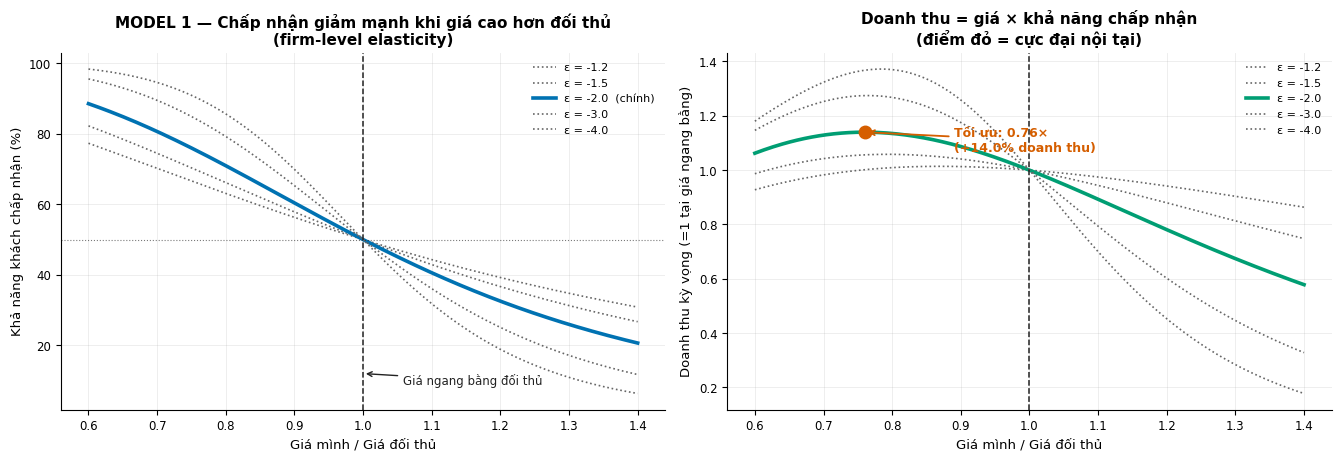

In [5]:
ty_le = np.linspace(0.60, 1.40, 300)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))

for eps in EPS_DAI:
    P = P_accept(ty_le, eps, P0)
    chinh = (eps == EPS_CHINH)
    ax[0].plot(ty_le, P*100, color=BLUE if chinh else MUT, lw=2.6 if chinh else 1.2,
               ls="-" if chinh else ":", label=f"ε = {eps}" + ("  (chính)" if chinh else ""))
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--")
ax[0].axhline(P0*100, color=INK, lw=0.8, ls=":", alpha=0.6)
ax[0].annotate("Giá ngang bằng đối thủ", xy=(1.0, 12), xytext=(1.16, 9),
               fontsize=8.5, color=INK, ha="center",
               arrowprops=dict(arrowstyle="->", color=INK, lw=1))
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("Khả năng khách chấp nhận (%)")
ax[0].set_title("MODEL 1 — Chấp nhận giảm mạnh khi giá cao hơn đối thủ\n(firm-level elasticity)",
                fontweight="bold")
ax[0].legend(frameon=False, fontsize=8)

for eps in EPS_DAI:
    P = P_accept(ty_le, eps, P0); R = ty_le * P
    R = R / (1.0 * P_accept(1.0, eps, P0))
    chinh = (eps == EPS_CHINH)
    ax[1].plot(ty_le, R, color=GREEN if chinh else MUT, lw=2.6 if chinh else 1.2,
               ls="-" if chinh else ":", label=f"ε = {eps}")
    if chinh:
        i = int(np.argmax(R))
        ax[1].plot(ty_le[i], R[i], "o", color=RED, ms=9, zorder=6)
        ax[1].annotate(f"Tối ưu: {ty_le[i]:.2f}×\n(+{(R[i]-1)*100:.1f}% doanh thu)",
                       xy=(ty_le[i], R[i]), xytext=(ty_le[i]+0.13, R[i]-0.07),
                       fontsize=9, fontweight="bold", color=RED,
                       arrowprops=dict(arrowstyle="->", color=RED, lw=1.3))
ax[1].axvline(1.0, color=INK, lw=1.1, ls="--")
ax[1].set_xlabel("Giá mình / Giá đối thủ")
ax[1].set_ylabel("Doanh thu kỳ vọng (=1 tại giá ngang bằng)")
ax[1].set_title("Doanh thu = giá × khả năng chấp nhận\n(điểm đỏ = cực đại nội tại)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "A1_model1_gia_doithu.png"); plt.show()

In [6]:
rows = []
for r in [0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20, 1.30]:
    row = {"gia/doi_thu": f"{r:.2f}x"}
    for eps in EPS_DAI:
        row[f"eps={eps}"] = f"{P_accept(r, eps, P0)*100:.1f}%"
    rows.append(row)
print("KHA NANG CHAP NHAN (%):")
display(pd.DataFrame(rows).set_index("gia/doi_thu"))

print("\nGIA TOI UU DOANH THU (cuc dai NOI TAI, khong phai bien luoi):")
opt = []
for eps in EPS_DAI:
    P = P_accept(ty_le, eps, P0); R = ty_le * P
    i = int(np.argmax(R))
    bien = (i == 0 or i == len(ty_le)-1)
    opt.append({"elasticity": eps, "gia_toi_uu": f"{ty_le[i]:.3f}x",
                "P(chap nhan)": f"{P[i]*100:.1f}%",
                "doanh_thu_vs_ngang_bang": f"{(R[i]/(1.0*P_accept(1.0,eps,P0))-1)*100:+.1f}%",
                "canh_bao": "BIEN LUOI!" if bien else "OK (cuc dai that)"})
display(pd.DataFrame(opt))

KHA NANG CHAP NHAN (%):


,eps=-1.2,eps=-1.5,eps=-2.0,eps=-3.0,eps=-4.0
gia/doi_thu,,,,,
0.70x,70.2%,74.5%,80.6%,89.5%,94.5%
0.80x,63.1%,66.1%,70.9%,79.2%,85.6%
0.90x,56.3%,57.8%,60.4%,65.3%,69.9%
0.95x,53.1%,53.8%,55.1%,57.6%,60.1%
1.00x,50.0%,50.0%,50.0%,50.0%,50.0%
1.05x,47.1%,46.3%,45.1%,42.7%,40.4%
1.10x,44.3%,42.9%,40.6%,36.1%,31.8%
1.20x,39.2%,36.7%,32.5%,25.1%,18.9%
1.30x,34.8%,31.3%,25.9%,17.2%,10.9%



GIA TOI UU DOANH THU (cuc dai NOI TAI, khong phai bien luoi):


,elasticity,gia_toi_uu,P(chap nhan),doanh_thu_vs_ngang_bang,canh_bao
0,-1.2,0.870x,58.3%,+1.4%,OK (cuc dai that)
1,-1.5,0.793x,66.8%,+5.8%,OK (cuc dai that)
2,-2.0,0.761x,74.9%,+14.0%,OK (cuc dai that)
3,-3.0,0.766x,83.2%,+27.5%,OK (cuc dai that)
4,-4.0,0.785x,87.4%,+37.2%,OK (cuc dai that)


### Kết luận Model 1

> **Chiều:** khả năng chấp nhận **giảm đơn điệu** khi giá mình cao hơn đối thủ — đúng quy luật.
>
> **Độ lớn:** với $\varepsilon_F = -2$, tăng giá **+10%** so với đối thủ làm khả năng chấp nhận
> giảm từ 50% xuống **~40,6%** — mất gần 1/5 lượng khách. Rất nhạy.
>
> **Giá tối ưu doanh thu nằm THẤP HƠN giá đối thủ** (~0,76×). Nghĩa là trong cạnh tranh trực tiếp,
> chiến lược tối ưu là **giảm giá để giành thị phần**, ngược hẳn với kết luận ở mức toàn thị trường.
>
> ⚠️ **Không mâu thuẫn với bằng chứng GMV của mentor.** Hai câu hỏi khác nhau:
> - *"Cả thị trường có nên tăng giá không?"* → **CÓ** (market-level, ít co giãn) ✅ khớp mentor
> - *"Mình có nên bán đắt hơn đối thủ không?"* → **KHÔNG** (firm-level, rất co giãn)

---

# 🌧️ MODEL 2 — Khả năng chấp nhận theo **THỜI TIẾT**

**Cơ chế:** mưa → lựa chọn thay thế (đi bộ, xe buýt, xe máy) kém hấp dẫn → WTP tăng → tại **cùng mức
giá**, khả năng chấp nhận **tăng**. Mức dịch chuyển WTP **đo từ dữ liệu: +4,61%**.

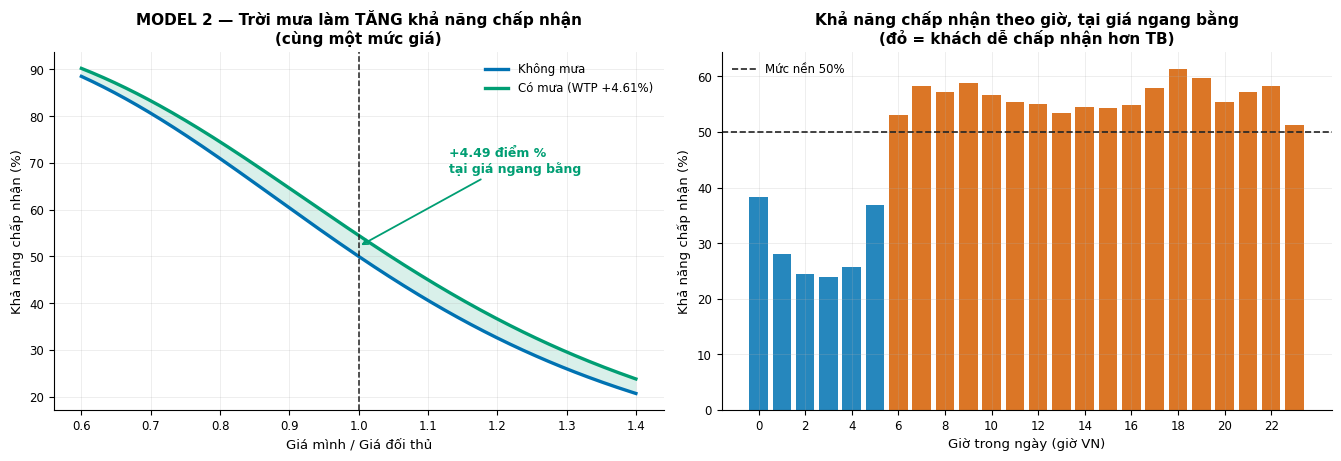

Tai gia ngang bang doi thu:
  Khong mua : 49.87%
  Co mua    : 54.36%   (+4.49 diem %)

Theo gio: thap nhat 23.83% (gio 3h) | cao nhat 61.31% (gio 18h)
  -> chenh 37.48 diem % = gap 8.3 lan tac dong cua mua


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))

P_kho = P_accept(ty_le, EPS_CHINH, P0, 0.0)
P_mua = P_accept(ty_le, EPS_CHINH, P0, DICH_MUA)
ax[0].plot(ty_le, P_kho*100, color=BLUE,  lw=2.4, label="Không mưa")
ax[0].plot(ty_le, P_mua*100, color=GREEN, lw=2.4, label=f"Có mưa (WTP {DICH_MUA*100:+.2f}%)")
ax[0].fill_between(ty_le, P_kho*100, P_mua*100, color=GREEN, alpha=0.15, lw=0)
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--")
i0 = int(np.argmin(abs(ty_le - 1.0)))
ax[0].annotate(f"+{(P_mua[i0]-P_kho[i0])*100:.2f} điểm %\ntại giá ngang bằng",
               xy=(1.0, (P_kho[i0]+P_mua[i0])/2*100), xytext=(1.13, 68),
               fontsize=9, fontweight="bold", color=GREEN,
               arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.3))
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("MODEL 2 — Trời mưa làm TĂNG khả năng chấp nhận\n(cùng một mức giá)", fontweight="bold")
ax[0].legend(frameon=False)

gio = np.arange(24)
P_gio = np.array([P_accept(1.0, EPS_CHINH, P0, DICH_GIO[h]) for h in gio])
ax[1].bar(gio, P_gio*100, color=[RED if v > P0 else BLUE for v in P_gio], alpha=0.85)
ax[1].axhline(P0*100, color=INK, lw=1.2, ls="--", label=f"Mức nền {P0*100:.0f}%")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Khả năng chấp nhận (%)")
ax[1].set_title("Khả năng chấp nhận theo giờ, tại giá ngang bằng\n(đỏ = khách dễ chấp nhận hơn TB)",
                fontweight="bold")
ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(frameon=False)

plt.tight_layout(); plt.savefig(HINH / "A2_model2_thoitiet_gio.png"); plt.show()

print(f"Tai gia ngang bang doi thu:")
print(f"  Khong mua : {P_kho[i0]*100:.2f}%")
print(f"  Co mua    : {P_mua[i0]*100:.2f}%   ({(P_mua[i0]-P_kho[i0])*100:+.2f} diem %)")
print(f"\nTheo gio: thap nhat {P_gio.min()*100:.2f}% (gio {gio[P_gio.argmin()]}h) | "
      f"cao nhat {P_gio.max()*100:.2f}% (gio {gio[P_gio.argmax()]}h)")
print(f"  -> chenh {(P_gio.max()-P_gio.min())*100:.2f} diem % "
      f"= gap {(P_gio.max()-P_gio.min())/(P_mua[i0]-P_kho[i0]):.1f} lan tac dong cua mua")

### Kết luận Model 2

> **Chiều:** mưa làm **tăng** khả năng chấp nhận. Tương đương: có thể **tăng giá ~4,6% khi mưa** mà
> vẫn giữ nguyên tỷ lệ chấp nhận.
>
> **Giờ mạnh hơn thời tiết rất nhiều** — biên độ WTP theo giờ **50%** so với mưa **4,6%**, tức gấp
> ~8,3 lần (đo trên điểm % khả năng chấp nhận). Nhất quán với báo cáo tuần 2: η(giờ → hệ số nhân) = 0,702 vs η(thời tiết) = 0,153.
>
> **Hàm ý vận hành:** ưu tiên tín hiệu **giờ** hơn **thời tiết** khi điều chỉnh giá.

---

## 6. Phân tích độ nhạy — kết luận nào **vững** trên toàn dải giả định?

In [8]:
rows = []
for eps in EPS_DAI:
    P = P_accept(ty_le, eps, P0); R = ty_le * P
    i = int(np.argmax(R))
    P_k = P_accept(1.0, eps, P0, 0.0); P_m = P_accept(1.0, eps, P0, DICH_MUA)
    Pg = np.array([P_accept(1.0, eps, P0, DICH_GIO[h]) for h in range(24)])
    rows.append({
        "elasticity": eps,
        "gia_toi_uu": round(ty_le[i], 3),
        "toi_uu < gia doi thu?": "CO" if ty_le[i] < 1 else "KHONG",
        "mua_tang_chap_nhan_(diem%)": round((P_m-P_k)*100, 2),
        "bien_do_gio_(diem%)": round((Pg.max()-Pg.min())*100, 2),
        "gio_manh_hon_mua?": "CO" if (Pg.max()-Pg.min()) > (P_m-P_k) else "KHONG",
    })
bang_ds = pd.DataFrame(rows)
display(bang_ds)

print("TINH VUNG cua cac ket luan tren toan dai elasticity:")
print(f"  1. Gia toi uu THAP HON gia doi thu : {bang_ds['toi_uu < gia doi thu?'].eq('CO').sum()}/{len(bang_ds)}")
print(f"  2. Mua LAM TANG kha nang chap nhan : {(bang_ds['mua_tang_chap_nhan_(diem%)'] > 0).sum()}/{len(bang_ds)}")
print(f"  3. Gio manh hon thoi tiet          : {bang_ds['gio_manh_hon_mua?'].eq('CO').sum()}/{len(bang_ds)}")

,elasticity,gia_toi_uu,toi_uu < gia doi thu?,mua_tang_chap_nhan_(diem%),bien_do_gio_(diem%),gio_manh_hon_mua?
0,-1.2,0.870,CO,2.70,23.62,CO
1,-1.5,0.793,CO,3.37,29.05,CO
2,-2.0,0.761,CO,4.49,37.48,CO
3,-3.0,0.766,CO,6.72,51.72,CO
4,-4.0,0.785,CO,8.91,62.60,CO


TINH VUNG cua cac ket luan tren toan dai elasticity:
  1. Gia toi uu THAP HON gia doi thu : 5/5
  2. Mua LAM TANG kha nang chap nhan : 5/5
  3. Gio manh hon thoi tiet          : 5/5


## 7. Kết luận & hạn chế

### Trả lời trực tiếp 2 câu hỏi của mentor

| Model | Câu hỏi | Trả lời |
|---|---|---|
| **1** | Biết **giá đối thủ** → chấp nhận tăng hay giảm? | **GIẢM mạnh**. Tăng giá +10% so với đối thủ → chấp nhận giảm từ 50% xuống ~40,6% |
| **2** | Biết **thời tiết** → chấp nhận tăng hay giảm? | **TĂNG** khi mưa (+4,61% WTP). Nhưng **giờ cao điểm mạnh hơn ~8,3 lần** |

### Ba kết luận **vững** trên toàn dải $\varepsilon_F \in [-1{,}2;\ -4{,}0]$

1. Giá tối ưu doanh thu **thấp hơn** giá đối thủ (cạnh tranh trực tiếp rất co giãn)
2. Mưa **làm tăng** khả năng chấp nhận
3. **Giờ trong ngày** tác động mạnh hơn **thời tiết** rất nhiều

### 🔑 Phát hiện quan trọng nhất — hai câu hỏi khác nhau, hai câu trả lời ngược nhau

| Câu hỏi | Loại elasticity | Trả lời |
|---|---|---|
| Cả thị trường có nên tăng giá? | Market ($\approx -0{,}5$) | **CÓ** — khớp bằng chứng GMV +10% của mentor |
| Mình có nên bán đắt hơn đối thủ? | Firm ($\approx -2{,}0$) | **KHÔNG** — mất khách vào tay đối thủ |

> Nhầm 2 loại elasticity này là lỗi nghiêm trọng trong định giá cạnh tranh. Phiên bản đầu của
> notebook này đã mắc lỗi đó và cho ra kết quả vô nghĩa ("tăng giá vô hạn").

### ⚠️ Hạn chế phải nêu rõ

| Hạn chế | Chi tiết |
|---|---|
| **Không có nhãn thật** | Toàn bộ là mô phỏng dưới giả định, chưa kiểm chứng bằng hành vi khách thật |
| **`P₀ = 0,5` là quy ước** | Giả định 2 người chơi đối xứng. Thực tế phụ thuộc thị phần |
| **`ε_F` là tham số ngoài** | Suy từ `ε_M` + thị phần ước tính, cần mentor xác nhận |
| **Global, không cá nhân hoá** | Đúng phạm vi cho phép, nhưng chưa dùng được cho personalized pricing |
| **WTP suy từ giá cân bằng** | Giả định thị trường cân bằng ở mức chấp nhận ổn định |
| **Mô hình tĩnh** | Không tính phản ứng của đối thủ (đối thủ cũng sẽ giảm giá theo) |

### 📮 Câu hỏi cần gửi mentor

1. **Trong thí nghiệm classical algo (+10% GMV), giá tăng trung bình bao nhiêu %?**
   → Chốt được `ε_MARKET` theo thị trường VN thật.
2. **Thị phần XanhSM so với đối thủ chính khoảng bao nhiêu?**
   → Cần để quy đổi `ε_MARKET` → `ε_FIRM` (tham số quan trọng nhất của Model 1).
3. GMV +10% đo trên **cùng kỳ** hay so **baseline trước đó**? Có kiểm soát mùa vụ không?
4. Mức chấp nhận nền `P₀` khi giá ngang bằng đối thủ, thực tế khoảng bao nhiêu?
5. Team đang dùng dạng hàm nào cho acceptance model (logit, hazard, hay khác)?